# Verifying Abaqus's Built-In Hashin Damage Model on a Single Shell Element

## Introduction

Structural failure does not have to be a single disruptive event. Long before a structure loses all load-carrying capacity, damage typically initiates locally, at whatever flaw or stress concentration is
most severe, and then *grows* — a crack lengthens, a region of material degrades, load
redistributes to whatever is still intact. **Progressive damage analysis** (PDA) is the
general modeling philosophy built around this observation: represent failure as a *process*
that initiates locally once a criterion is met, then evolves as stiffness degrades, rather
than treating failure as a single instantaneous stress limit
([Matzenmiller et al., 1995](https://doi.org/10.1016/0167-6636%2894%2900053-0);
[Barbero, 2023](https://doi.org/10.1201/9781003108153)).
This is not a composites-specific idea — ductile metals, concrete, and rock are all modeled
with progressive-damage or progressive-fracture frameworks of their own, each with its own
initiation criteria and evolution laws suited to how *that* material actually fails.

When working with composite materials, what makes a structure demanding to model is that it
can fail through several distinct, coexisting mechanisms at the level of a single ply —
before any structural detail like a hole, joint, or free edge is even introduced. A
unidirectional fiber-reinforced ply is a composite of two very different constituents: stiff,
strong fibers embedded in a much more compliant, weaker matrix. Loaded along the fibers, it
resists mainly through fiber stiffness and eventually fails by fiber rupture (tension) or
fiber micro-buckling/kinking (compression); loaded transverse to the fibers, it resists mainly
through the matrix and the fiber/matrix interface, and fails by matrix cracking (tension) or
matrix crushing and shear cracking (compression). In a multi-ply laminate, plies can also
separate from each other entirely (delamination) once interlaminar stresses get large enough.
None of these mechanisms is "the" failure mode of the material — they coexist, and which one
governs depends on the loading direction and sign. Damage in one mode also redistributes load
into the surviving material, which can trigger the next mode. This is exactly why *many*
different failure criteria exist for composites in the literature (Puck, LaRC,
Hashin, and others) — each is a different way of turning "which stress state triggers which
of these modes" into a mathematical condition, and the criteria mostly disagree on the details
of that mapping, not on the existence of the mode split itself.

**Why this is worth getting right.** Fiber-reinforced composites are now primary load-bearing structure in both airframes and wind-turbine blades — two of the largest applications of this material class. Aviation's certification framework has for decades been built around an explicit **damage-tolerance** philosophy rather than a single ultimate-strength check: a structure must be shown to tolerate realistic damage (an impact dent, a manufacturing flaw) without failing, and any damage that does exist must not grow to criticality between scheduled inspections ([Janeikaitė et al., 2025](https://doi.org/10.3390/ma18214938)). Wind-turbine blades are moving in the same direction but haven't fully arrived: current practice is still largely a *safe-life* approach relying on large safety factors, and the shift toward an explicit damage-tolerant methodology — accepting inherent flaws and impact damage while relaxing those margins — is an active area of development rather than settled certification practice ([Baharvand et al., 2025](https://doi.org/10.3390/ma18102214)). Either way, predicting *how* damage grows — not just the load at which it starts — is exactly the question PDA is built to answer, which is why it's an increasingly central tool in both fields' design processes, and a certification requirement in aviation's case.


**The ingredients of a progressive damage analysis**, regardless of which specific criterion
is chosen, are the same four:

1. A **damage-initiation criterion** per failure mode: a function of the local stress state
   that reaches a critical value (typically 1) the instant that mode begins to develop.
2. A **damage-evolution law**: once initiated, how stiffness degrades from that point on —
   usually governed by a fracture energy, so the energy dissipated by full failure is a real
   material property rather than an artifact of the mesh.
3. **Stiffness degradation** fed back into the constitutive law, so a "damaged" material
   point carries less stress for the same strain going forward.
4. An **equilibrium solver** able to trace the response through the resulting negative-stiffness post-peak branch, since a damaged structure's load-displacement curve
   can turn over and decrease even as displacement keeps increasing.

This notebook exercises all four ingredients using **one specific criterion**: the
[Hashin (1980)](https://doi.org/10.1115/1.3153664) failure criteria, which are Abaqus's
built-in progressive damage model for fiber-reinforced composites, automated end-to-end
through **abqpy**. Rather than building a full laminate straight away — where a mesh, a
stress concentration, and multiple plies would tangle every one of these ingredients
together in whatever curve came out — we isolate the smallest possible test: **a single
Abaqus S4R shell element**, one ply, loaded to excite **exactly one failure mode: fiber
tension**. This is standard practice for verifying a material model: isolate one mechanism
at a time, on the simplest possible geometry, before trusting the same ingredients in
anything bigger. The same model, loaded along the other axis or with the opposite sign,
gives you the other three Hashin modes (fiber compression, matrix tension, matrix
compression) — a natural next exercise once this one makes sense to you.

## Learning objectives

- Understand what progressive damage analysis represents physically, and why a composite ply
  in particular already fails through several coexisting mechanisms even before any structural
  detail is introduced.
- Understand what Abaqus's built-in Hashin damage model represents physically and
  numerically, not just which keywords turn it on.
- Build the smallest possible verification model — a single shell element, one ply, one
  isolated failure mode — and reproduce it as a scripted, reproducible Python workflow.
- Learn to read the model's damage-initiation and damage-evolution field variables
  (`HSNFTCRT`, `DAMAGEFT`, ...) and connect them back to the underlying equations.
- Understand why boundary conditions matter as much as material properties for getting a
  clean, physically meaningful uniaxial-tension state.
- Check the simulated response against closed-form analytical predictions (elastic
  stiffness, initiation displacement, peak force, full-failure displacement) rather than
  trusting the curve on sight.
- Run the same model with geometric nonlinearity switched **off** and **on**, to isolate how
  much of any remaining gap to the analytical (small-strain) predictions is genuine nonlinear
  kinematics rather than solver discretization.

## Theoretical background

Before building the model, let's establish the theory each piece of it rests on: the specific
failure criterion we're testing, what happens once it's activated, and the numerical machinery
needed to trace the resulting response all the way to failure.

### Hashin failure criteria

**Hypotheses.** [Hashin (1980)](https://doi.org/10.1115/1.3153664) failure criteria apply to a **unidirectional fiber-reinforced lamina** — a single ply in which every fiber runs parallel to one direction (not a woven or otherwise
multi-directional fabric, which needs a different set of criteria entirely). They are stated
in their **2D, plane-stress form**: the ply is thin enough, and loaded in its own plane, that
through-thickness stresses are negligible — the only stress components that matter are the
in-plane ones, expressed in the ply's own material axes (1 = along the fibers, 2 = transverse
to the fibers). We write $\hat\sigma_{11}$, $\hat\sigma_{22}$, $\hat\tau_{12}$ for the
**effective (undamaged) stress** — the stress the material would carry if none of it had
degraded yet; this is the quantity the criteria actually test, not the already-degraded
stress the element outputs once damage has started. A 3D version of the criteria exists, but we will not use it here since our single-element test is strictly 2D.

**What kind of criterion this is.** Hashin is explicit about ruling out the alternative of resolving stresses separately inside the fiber and matrix constituents and tracking the coalescence of microcracks into a macroscopic
failure — he calls that "an intractable task," since the microstructural failure process is
far too complex to analyze directly. Instead, the criteria are written entirely in terms of
**average (smeared/homogenized) ply stresses** — exactly the $\sigma_{11}, \sigma_{22},
\tau_{12}$ a finite element code actually computes and outputs for a ply, with no attempt to
resolve what is happening to an individual fiber or to the matrix between fibers. The
quadratic form of the equations below is also a deliberate, admitted choice of mathematical
convenience, not physics — Hashin describes it as "based on curve fitting considerations and
not on physical reasoning," chosen because it is the simplest form that fits typical strength
test data reasonably well with a manageable number of coefficients.

**Fiber mode and matrix mode are macroscopic fracture patterns, not a "fiber stress vs.
matrix stress" split.** Hashin observes two macroscopically distinct fracture patterns in
unidirectional composites: fibers rupture in tension or kink/buckle in compression (the
**fiber mode**), or a crack forms running parallel to the fibers, cutting through the matrix
and the fiber/matrix interface (the **matrix mode**). Each mode is associated with an
approximate **failure plane** — the plane on which the criterion assumes fracture actually
occurs — and the criterion for that mode is built from whichever *average ply stress
components act as tractions on that plane*. This is the actual logic that determines which
stress enters which criterion — not "fiber stresses go in the fiber criterion":
- The **fiber-mode failure plane** is the cross-section cut perpendicular to the fibers (the
  plane an inspection of a broken fiber would show). The tractions on that plane are the
  normal stress along the fiber direction, $\hat\sigma_{11}$, and the shear stress acting
  *within* that plane, $\hat\tau_{12}$. That is why $\hat\tau_{12}$ appears in the fiber-**tension** criterion
  below, even though fibers don't "carry shear" in any simple sense: it is a shear traction
  resolved onto the fiber-failure plane, not a statement about which constituent resists
  which stress component.
- The **matrix-mode failure plane** is a longitudinal split running parallel to the fibers.
  The tractions on *that* plane are the transverse normal stress $\hat\sigma_{22}$ and the
  shear stress acting within it, $\hat\tau_{12}$. $\hat\sigma_{11}$ does not act on this plane at all, since the plane
  runs parallel to the fiber direction — which is exactly why it is absent from both matrix
  criteria below.

Each primary mode is then split again into **tension and compression**, because both the
mechanism and the measured strength genuinely differ between the two: fibers break in tension
but buckle in compression; the matrix-mode crack opens under transverse tension but crushes
and shears under transverse compression.

With $X_T, X_C$ the longitudinal (fiber-direction) tensile and compressive strengths, $Y_T,
Y_C$ the transverse (matrix-direction) tensile and compressive strengths, $S_L$ the
longitudinal shear strength, $S_T$ the transverse shear strength, and $\alpha$ a coefficient
weighting how strongly the shear traction on the fiber-failure plane contributes relative to
the normal traction — [Lapczyk & Hurtado (2007)](https://doi.org/10.1016/j.compositesa.2007.01.017) note that
$\alpha=1$ recovers Hashin's own (1980) choice, while $\alpha=0$ (together with $S_T=0.5Y_C$)
recovers the earlier [Hashin & Rotem (1973)](https://doi.org/10.1177/002199837300700404) criterion, which drops
the shear contribution to fiber failure entirely — the four Hashin criteria are:

**Fiber tension** ($\hat\sigma_{11} \geq 0$):
$$
F_{ft} = \left(\frac{\hat\sigma_{11}}{X_T}\right)^2 + \alpha\left(\frac{\hat\tau_{12}}{S_L}\right)^2
$$

**Fiber compression** ($\hat\sigma_{11} < 0$):
$$
F_{fc} = \left(\frac{\hat\sigma_{11}}{X_C}\right)^2
$$

**Matrix tension** ($\hat\sigma_{22} \geq 0$):
$$
F_{mt} = \left(\frac{\hat\sigma_{22}}{Y_T}\right)^2 + \left(\frac{\hat\tau_{12}}{S_L}\right)^2
$$

**Matrix compression** ($\hat\sigma_{22} < 0$):
$$
F_{mc} = \left(\frac{\hat\sigma_{22}}{2S_T}\right)^2 + \left[\left(\frac{Y_C}{2S_T}\right)^2 - 1\right]\frac{\hat\sigma_{22}}{Y_C} + \left(\frac{\hat\tau_{12}}{S_L}\right)^2
$$

Damage **initiates** in a given mode the moment its criterion reaches $F \geq 1$. Abaqus
reports these four values directly as field output variables `HSNFTCRT`, `HSNFCCRT`,
`HSNMTCRT`, `HSNMCCRT` — watching one of these cross 1.0 *is* watching the criterion trigger, and the element begin to degrade in that mode.

Our single-element test applies pure uniaxial tension along the fiber direction with (as
we'll check explicitly) zero shear stress, so only the first term of $F_{ft}$ is ever
non-zero here — $\alpha$ genuinely doesn't matter for this particular test, even though we
still have to set it to *something*.

### After damage initiation: energy-based damage evolution

Reaching $F=1$ in a mode doesn't mean the material vanishes there — it means **stiffness
starts to degrade** in that mode. Abaqus tracks this with a **damage variable** $d$ that grows
from 0 (undamaged) to 1 (that mode's stiffness fully removed). Following
[Lapczyk & Hurtado (2007)](https://doi.org/10.1016/j.compositesa.2007.01.017) — the paper
describing Abaqus's built-in evolution law — there is a **separate damage variable for each of
the four modes**: $d_{ft}, d_{fc}, d_{mt}, d_{mc}$. These are exactly what Abaqus reports as
the field output variables `DAMAGEFT`, `DAMAGEFC`, `DAMAGEMT`, `DAMAGEMC` — one number per
mode, per material point, climbing from 0 the instant that mode's criterion initiates.

**How $d$ enters the equations.** The damage variables degrade the ply's stiffness matrix
directly: the fiber-direction modulus becomes $(1-d_f)E_1$, the transverse modulus becomes
$(1-d_m)E_2$, and the shear modulus becomes $(1-d_s)G_{12}$, where $d_f$ and $d_m$ are
whichever of the tension/compression pair is currently active for that mode (and $d_s$ can be expressed as a function of the other damage variables). Equivalently: the **effective stress** $\hat\sigma$ that the Hashin criteria above are
evaluated against is related to the **nominal stress** $\sigma$ — the stress the element
actually carries — by
$$
\sigma = (1-d)\,\hat\sigma .
$$
It is this degraded nominal stress that gets assembled into the element's internal force
vector, so *this* is what the equilibrium equations actually balance against the applied load
from the moment damage initiates onward — a fully damaged material point ($d=1$) carries no
stress at all in that mode, regardless of how much strain is applied to it.

We now have one ingredient: damage variables that degrade stiffness. What's still missing is a
rule for *how fast* each $d$ actually grows once its mode initiates — that's what is outlined in the steps below.

**Step 1 — we need a post-peak law.** $\sigma=(1-d)\hat\sigma$ only tells us how damage
degrades stress *given* $d$; it says nothing about how $d$ grows as the material keeps
straining past initiation. The missing piece is a **softening branch**: a rule for how stress
falls off after the peak, as a function of continued deformation. The simplest physically
reasonable choice — and the one Abaqus uses by default — is that stress falls off **linearly**
from the strength at initiation down to zero.

**Step 2 — why that softening law can't be written directly in stress-strain terms.**
The natural first guess is to draw that falling line directly in $\sigma$-$\varepsilon$ space:
stress drops linearly from $(\varepsilon_0, X)$ to some $(\varepsilon_f, 0)$. This looks
reasonable for a single material point, but it breaks down as soon as you mesh a real
structure with more than one element, and the reason is worth working through concretely.
Once a point starts softening, it becomes *more compliant* than its still-elastic neighbors —
so as the structure keeps stretching, essentially all of the *additional* deformation piles
into that one softening region, while the elastic neighbors barely stretch any further at all.
The energy dissipated by full failure at that softening point is [energy per unit volume, the
area under its own $\sigma$-$\varepsilon$ curve] $\times$ [the **volume** of material doing the
softening]. If you refine the mesh, the softening localizes into a *smaller* element — less
volume — so a finer mesh dissipates **less** total energy for what is supposed to be the same
physical crack. Taken to the limit of an arbitrarily fine mesh, the energy needed to fully fail
the structure shrinks to essentially nothing. That is a mesh-refinement artifact, not
physics: a real crack takes a fixed amount of energy to grow, set by the material and the
crack's **area**, regardless of how the analyst happens to have meshed the part
([Lapczyk & Hurtado, 2007](https://doi.org/10.1016/j.compositesa.2007.01.017)).

**Step 3 — the fix: soften against an equivalent *displacement*, not strain.** If the
softening law is instead written in terms of an **equivalent displacement**
$$
\delta = L_c\,\varepsilon,
$$
where $L_c$ is the element's **characteristic length** (the square root of the element's area,
for the shell elements used here), then the localization described above no longer changes the
*energy per unit crack area* the law implies — $L_c$ scales out the mesh dependence exactly,
because a smaller element has both less volume *and* a smaller $L_c$, and the two cancel. This
is the **crack-band** approach: keep the softening shape, but express it against $\delta$
instead of $\varepsilon$.

**Step 4 — what the fracture energy actually is.** With softening expressed in
$\sigma$-$\delta$ space, the **fracture energy** $G_c$ is simply defined as the energy
dissipated *per unit crack area* between initiation and full failure — i.e. the **area under
the full $\sigma$-$\delta$ curve**. This is a genuine material property (tabulated from
experiments), independent of mesh size, which is the entire point of the previous two steps. Note that the definition of energy dissipated between initiation and full failure and that of area under the full $\sigma$-$\delta$ curve actually coincide, because both the elastic energy stored up to the onset of damage and the external work done over the softening branch need to be dissipated in an irreversible manner for full failure to occur.

**Step 5 — linear softening in $\sigma$-$\delta$ space.** Stress rises linearly from the
origin to $(\delta_0, X)$, where $\delta_0$ is the displacement at initiation and $X$ is the strength, then drops
linearly to $(\delta_f, 0)$, where $\delta_f$ is the displacement at full failure. [Lapczyk & Hurtado (2007)](https://doi.org/10.1016/j.compositesa.2007.01.017) set $\delta_f$ so that the area under this whole bilinear curve — a triangle of
base $\delta_f$ and height $X$ — equals the specified fracture energy:
$$
G_c = \tfrac12 X \delta_f \quad\Longrightarrow\quad \delta_f = \frac{2 G_c}{X}.
$$

**Step 6 — only now can we write down how $d$ evolves.** Everything above defines the target
*shape* of the $\sigma$-$\delta$ curve; the damage variable $d$ is then defined, as the very
last step, precisely so that $\sigma=(1-d)\hat\sigma$ traces that shape:
$$
d = \frac{\delta_f(\delta-\delta_0)}{\delta(\delta_f-\delta_0)}, \qquad \delta_0\le\delta\le
\delta_f.
$$

In other words, the evolution of $d$ is a function of $\delta$, which in turn is a *consequence* of choosing a linear softening law and a fracture energy.

Let's plot this bilinear law for the fiber tension mode of the single shell element model that we are going to analyze later. As you will see, the properties that we are going to use are $X_T=990$ MPa, $E_1=40600$ MPa, $G_{fT}=1290$ N/mm, and $L_c=\sqrt{\text{element area}}=\sqrt{10 \mathrm{mm} \times10\ \mathrm{mm}}=10$ mm. The displacements at initiation and full failure are then:
$$
\delta_0 = \frac{X_T}{E_1}L_c = 0.244\ \mathrm{mm}, \qquad
\delta_f = \frac{2 G_{fT}}{X_T} = 2.606\ \mathrm{mm}.
$$
The plot below draws the bilinear law with these actual numbers, shading the triangle whose area equals $G_{fT}$.

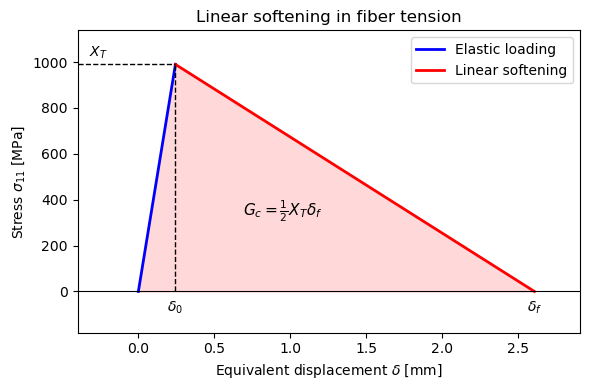

delta_0 = 0.2438 mm, delta_f = 2.6061 mm, G_c = 0.5*X_T*delta_f = 1290.0 N/mm


In [1]:
import matplotlib.pyplot as plt

# This notebook's own fiber-tension values (see the material table below), used directly
# rather than an abstract schematic — the numbers here are the same ones the simulation
# further down will reproduce.
X_T = 990.0  # MPa, fiber tensile strength (Nelson, Riddle & Cairns, 2017)
E1 = 40600.0  # MPa, fiber-direction modulus
G_fT = 1290.0  # N/mm, fiber-tension fracture energy (literal source value)
L_c = 10.0  # mm, characteristic length = sqrt(element area) = sqrt(10x10 mm) for this single-element geometry

delta_0 = X_T / E1 * L_c  # mm, equivalent displacement at damage initiation (end of the elastic branch)
delta_f = 2 * G_fT / X_T  # mm, equivalent displacement at full failure — measured from the ORIGIN, per the theory above

# The bilinear curve is the three points (0,0) -> (delta_0, X_T) -> (delta_f, 0); shading the
# area under the whole thing (not just the delta_0 -> delta_f segment) is what gives a triangle
# of base delta_f and height X_T, whose area is exactly G_fT regardless of where delta_0 falls
# in between (base * height / 2, independent of the apex's position along the base).
delta_curve = [0, delta_0, delta_f]
sigma_curve = [0, X_T, 0]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0, delta_0], [0, X_T], "b-", lw=2, label="Elastic loading")  # (0,0) -> (delta_0, X_T)
ax.plot([delta_0, delta_f], [X_T, 0], "r-", lw=2, label="Linear softening")  # (delta_0, X_T) -> (delta_f, 0)
ax.plot([-0.4, delta_0], [X_T, X_T], "k--", lw=1)  # horizontal line at the strength, for reference
ax.plot([delta_0, delta_0], [0, X_T], "k--", lw=1)  # vertical line at delta_0, for reference
ax.fill_between(delta_curve, sigma_curve, color="red", alpha=0.15)  # shade the full triangle, area = G_fT
ax.annotate(r"$\delta_0$", xy=(delta_0, 0), xytext=(delta_0, -90), ha="center")
ax.annotate(r"$\delta_f$", xy=(delta_f, 0), xytext=(delta_f, -90), ha="center")
ax.annotate(r"$X_T$", xy=(0, X_T), xytext=(-0.2, X_T*1.05), va="center", ha="right")
ax.text((0 + delta_0 + delta_f) / 3, X_T / 3, r"$G_c=\frac{1}{2}X_T\delta_f$", ha="center", fontsize=11)  # roughly at the triangle's centroid
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel(r"Equivalent displacement $\delta$ [mm]")
ax.set_ylabel(r"Stress $\sigma_{11}$ [MPa]")
ax.set_title("Linear softening in fiber tension")
ax.legend(loc="upper right")
ax.set_xlim(-0.4, delta_f + 0.3)
ax.set_ylim(-180, X_T * 1.15)
fig.tight_layout()
plt.show()

print(f"delta_0 = {delta_0:.4f} mm, delta_f = {delta_f:.4f} mm, "
      f"G_c = 0.5*X_T*delta_f = {0.5 * X_T * delta_f:.1f} N/mm")

This bilinear law is what we now hand to Abaqus's Hashin damage-evolution model. What's still missing is *how* Abaqus actually traces this shape
numerically once damage starts feeding back into the stiffness — the solver question the next section addresses.

### Tracing the softening response: why a nonlinear solver, and why displacement control

**Why a nonlinear solver at all.** Abaqus solves for equilibrium by balancing the applied load
against the structure's internal force, $K(\mathbf{u})\,\mathbf{u} = \mathbf{F}$, where $K$ is
the stiffness. For a linear-elastic structure $K$ is constant, and one linear solve gives the
answer. Here it isn't, for at least one reason: the moment a mode's
damage variable $d$ starts climbing, the material's tangent stiffness depends on the current
state (the damage already accumulated) — so $K$ depends on $\mathbf{u}$ itself. If geometric
nonlinearity is also switched on (`nlgeom=ON` in Abaqus), $K$ depends on the current *deformed* geometry
too, adding a second source of nonlinearity on top of the material one — the results section
below runs this model both ways to see how much that second source actually matters here.
Abaqus handles both with Newton-Raphson: linearize around the current guess, solve, update,
and repeat until the residual (out-of-balance force) is small enough, for each increment of
the analysis.

**Load control vs. displacement control.** There are, in principle, two ways to drive a
nonlinear static step: prescribe the **load** and solve for the resulting displacement, or
prescribe the **displacement** and solve for the resulting reaction force. Our test prescribes
a displacement at the loaded edge (see the boundary conditions below), so displacement control
is the natural fit for *this* model. It is also usually the *easier* case for Newton-Raphson
once a structure starts softening: the controlled quantity (the prescribed displacement) can
simply keep increasing monotonically, and the solver only has to find whatever reaction force
currently balances it — even if that reaction force is decreasing.

## The model

With the theory in place, let's build the actual model: the geometry and element it uses, the
material data assigned to it, and the boundary conditions that turn it into a genuinely clean
uniaxial-tension test.

### Geometry and element

The part is a single flat **10 mm × 10 mm square**, representing one ply of the laminate,
meshed with **exactly one Abaqus S4R element** — a 4-node, reduced-integration shell element
with both membrane and bending stiffness. Reduced integration means the element uses a single
in-plane integration point per section point rather than four, which is standard practice for
shell elements: it avoids "shear locking" and is computationally cheaper. The trade-off is that under-integration can excite spurious zero-energy "hourglass" deformation modes, so S4R pairs reduced integration with built-in hourglass control to suppress them. Through the
thickness, Abaqus still evaluates the material response at several **section points** (5 by
default for a homogeneous shell section). The shell thickness is **0.2 mm**.

The distance between the fixed edge ($x=0$) and the loaded edge ($x=10$ mm) — is this test's **gauge length**, $L=10$ mm. This is the
single-element analogue of the gauge length on a real tensile-test coupon (the marked-off
region between the grips, excluded from the wider tabbed ends), and it's what turns the
prescribed edge displacement $U_1$ into a strain, $\varepsilon_{11}=U_1/L$.

Throughout this notebook series, we work in a **mm / N / MPa** consistent unit system: lengths in
mm, forces in N, stress/moduli/strengths in MPa (= N/mm²), and fracture energies in N/mm — the
material table below is already expressed this way. With a single element covering the whole
10×10 mm part, the element's **characteristic length** used for the energy-based softening law
above is $L_c=\sqrt{A}=\sqrt{10\times10}=10$ mm — for this particular geometry, numerically
equal to the gauge length $L$, though the two are conceptually different quantities ($L_c$ is
a mesh/regularization length, $L$ is the physical measurement length).

### Material: E-glass/epoxy unidirectional lamina

Properties below are sourced from
[Nelson et al. (2017)](https://doi.org/10.5194/wes-2-653-2017), a Sandia-sponsored
study built specifically around Abaqus's Hashin model for wind-blade fiberglass.

| Property | Value | Note |
|---|---|---|
| $E_1, E_2, \nu_{12}, G_{12}$ | 40600, 16300 MPa, 0.27, 16800 MPa | tension-column values from their Table 1; used for all loading directions as a simplification, since Abaqus's single elastic definition can't represent their separately-reported (slightly stiffer) compression-column values |
| $G_{13}, G_{23}$ | 16800, 6000 MPa | not reported by the source (a plane-strain-continuum-element study, no transverse shear); placeholders — irrelevant here since they only affect 3D transverse shear stiffness, and this test has none |
| $X_T, X_C, Y_T, Y_C, S_L, S_T$ | 990, 582, 60, 35, 112, 124 MPa | their Table 2, directly usable |
| $\alpha$ | 1 | set explicitly per [Hashin (1980)](https://doi.org/10.1115/1.3153664), as Nelson et al. also do; irrelevant to this specific test (zero shear stress) but part of the material definition regardless |
| $G_{fT}, G_{fC}, G_{mT}, G_{mC}$ | 1290, 757, 78, 45.5 N/mm | **see note below** |

**On the fracture energies**: Nelson et al.'s Table 2 reports these as
$1.29\times10^6$, $7.57\times10^5$, $7.8\times10^4$, $4.55\times10^4$ J/m² — the paper is
explicit that these are *approximated* (area-under-the-curve estimates), not measured. The
table above uses the literal conversion to this notebook series mm/N/MPa unit system
($1\ \mathrm{J/m^2} = 10^{-3}\ \mathrm{N/mm}$), with no further scaling. For fiber tension,
this gives $\delta_f=2G_{fT}/X_T\approx2.61$ mm (per the theory above), comfortably longer
than the initiation displacement $\delta_0\approx0.24$ mm — long enough that the softening
branch itself is captured by several increments in a single run with no manual tuning of the
increment size, even though (as the results section shows) the solver's automatic step-size
choice can still land its increments coarsely right around the sharp peak itself.

### Boundary conditions

A static analysis needs enough constraints to remove **rigid-body motion** — the six ways a
free body can move without straining at all (three translations, three rotations) — but no
more than that: any extra constraint beyond what removes rigid-body motion risks confining the
model against deformation it should physically be free to undergo, corrupting the very field
we're trying to isolate. The target field here is homogeneous uniaxial tension along $x$,
$U_1(x,y)=k_1x$, $U_2(x,y)=k_2y$, with $k_1>0$ (imposed stretch) and $k_2<0$ (free Poisson
contraction) — so the constraints below are each chosen to be exactly consistent with that
field, not merely sufficient to stop rigid-body drift:

- $U_1=0$ on the $x=0$ edge — consistent with the field ($U_1=k_1\cdot0=0$ for any $y$), and
  removes both the $x$-translation and the in-plane (about $z$) rotation, since it fixes two
  points that can't both stay at $U_1=0$ if the edge rotates in-plane.
- $U_2=0$ on the $y=0$ edge — likewise consistent with the field ($U_2=k_2\cdot0=0$ for any
  $x$), and removes the $y$-translation.
- $U_3=0$ on the $x=0$ edge and on the $y=0$ edge — together, three non-collinear nodes (the
  two edges share the corner at the origin) pin the plane $z=0$, removing the remaining two
  out-of-plane rotations and the $z$-translation, without constraining $U_3$ at the one corner
  $(10,10)$ that isn't on either edge.
- $U_1$ prescribed on the $x=10$ edge — this is the applied load.

That's six constraint directions removing exactly the six rigid-body modes, with every one of
them satisfied automatically by the target field itself — so none of them can generate a
spurious stress the way, for instance, also pinning $U_2=0$ along $y=10$ would (that would
prevent the free Poisson contraction the field requires, generating a transverse stress that
has nothing to do with the material and everything to do with an over-constrained model). $U_2$
is left completely free on the $y=10$ edge, and no rotational degree of freedom is constrained
anywhere.

## What to expect: analytical predictions

Before handing this off to Abaqus, it's worth writing down what a small-strain, linear
analytical model predicts for the four features of the response we'll be checking against —
partly as a sanity check, and partly because comparing against these numbers is what makes
the results section below more than "the curve looks about right." Using the cross-sectional
area $A=w\,t=10\times0.2=2\ \mathrm{mm^2}$ and gauge length $L=10$ mm from above:

- **Elastic stiffness**: $k = E_1 A / L$.
- **Initiation displacement**: $\delta_0 = (X_T/E_1)\,L$ — the displacement at which
  $\hat\sigma_{11}=X_T$, i.e. `HSNFTCRT` reaches 1.0.
- **Peak force**: $F_\text{peak} = X_T\,A$ — the force carried at the instant of initiation,
  before any stiffness has degraded.
- **Full-failure displacement**: $\delta_f=2G_{fT}/X_T$ (from the theory above) — the
  displacement at which `DAMAGEFT` reaches 1.0 and the fiber-tension stiffness is fully
  removed.

With $G_{fT}=1290$ N/mm and $X_T=990$ MPa, this last prediction works out to
$\delta_f\approx2.61$ mm — and that number is exactly why the Abaqus run below prescribes a
target displacement of $U_1=3$ mm at the loaded edge: comfortably past the predicted
full-failure point, with enough margin to actually capture the softening branch running out to
(near-)zero force, rather than stopping just short of it.

**These are small-strain, linear predictions — deliberately not tied to any geometric nonlinearities.** The results section below runs the actual Abaqus model twice: once with
**`nlgeom=OFF`**, which should reproduce these small-strain formulas almost exactly (the only
remaining gap being the solver's discrete increment spacing, which we will also
explicitly correct for), and once with **`nlgeom=ON`**, which accounts for geometric
nonlinearity these formulas simply don't — finite rotations, and the distinction between
engineering and true/logarithmic strain and between stress on the reference vs. current
cross-section. Running both lets us tell the two effects (discretization vs. genuine nonlinear
kinematics) apart, instead of guessing at how much each contributes to a single observed gap.

In [2]:
E1 = 40600.0  # MPa
X_T = 990.0  # MPa
G_fT = 1290.0  # N/mm
width, thickness, gauge = 10.0, 0.2, 10.0  # mm
area = width * thickness  # mm^2, cross-sectional area carrying the load

k_pred = E1 * area / gauge  # N/mm, elastic stiffness
delta0_pred = (X_T / E1) * gauge  # mm, displacement at damage initiation
Fpeak_pred = X_T * area  # N, force at the instant of initiation
deltaf_pred = 2.0 * G_fT / X_T  # mm, displacement at full failure (measured from the origin)

print(f"Predicted elastic stiffness:          {k_pred:8.1f} N/mm")
print(f"Predicted initiation displacement:    {delta0_pred:8.4f} mm")
print(f"Predicted peak force:                 {Fpeak_pred:8.1f} N")
print(f"Predicted full-failure displacement:  {deltaf_pred:8.4f} mm")

Predicted elastic stiffness:            8120.0 N/mm
Predicted initiation displacement:      0.2438 mm
Predicted peak force:                   1980.0 N
Predicted full-failure displacement:    2.6061 mm


These four numbers — $k$, $\delta_0$, $F_\text{peak}$, $\delta_f$ — are the yardstick
every simulated result from here on gets checked against. With them written down, it's time
to actually build the model that's supposed to reproduce them.

## Building the model in Abaqus

This model is built with **abqpy** — type hints for Abaqus/Python scripting, so the code
looks like ordinary, type-checked Python 3 rather than the somewhat awkward native Abaqus
scripting style.

One thing about abqpy is essential to understand before running anything: importing `abaqus`
(or `odbAccess`) doesn't just give access to Abaqus's classes — it *immediately* hands the
entire currently-running script off to a real Abaqus installation and terminates the calling
Python process (`abaqus/__init__.py` calls `abqpy.run()` as its first executable line, which locates the real Abaqus executable,
resubmits the whole script to it via `abaqus cae noGUI=...`, and calls `sys.exit(0)`). For a
plain `.py` script run directly, this is a clean, self-relaunching pattern. Run **inside a
live Jupyter kernel**, it would kill that kernel — ending the interactive session this
notebook is otherwise built around.

**This is why the actual model-building code lives in a standalone script,
[`scripts/build_fiber_tension.py`](../scripts/build_fiber_tension.py), independent of this or
any other notebook**. This notebook only *invokes* it, via `subprocess`, so only that child process is affected by the self-relaunch above; everything
after that — loading and plotting results — runs normally in this notebook's own live kernel.

**What the script does, step by step**, every time it runs:

1. Build the 10 mm $\times$ 10 mm shell geometry and mesh it with exactly one S4R element.
2. Define the E-glass/epoxy material: elastic properties, the six Hashin strengths, and the
   energy-based damage evolution law.
3. Assign the shell section and material orientation, then mesh the part and create the assembly instance.
4. Define the node sets used for boundary conditions and output, and the Static, General step.
5. Apply the boundary conditions described below, with the loaded edge driven to a target
   displacement.
6. Configure field and history output.
7. Submit the job, wait for it to finish, then open the resulting `.odb` and write a plain
   JSON file with the force-displacement history and the damage/criterion field variables.

**How to run it.** The script takes its parameters as `key=value` tokens on the command line,
all optional:

```
python build_fiber_tension.py nlgeom=OFF X_T=990 U1=3.0 out=fiber_tension_results_nlgeom_off.json
```

- `nlgeom` — `ON` or `OFF`, geometric nonlinearity for the Static step (default `ON`)
- `X_T` — fiber tensile strength in MPa (default `990.0`)
- `U1` — target displacement at the loaded edge in mm, the applied `DisplacementBC`'s
  magnitude (default `3.0`)
- `out` — output JSON filename (default `fiber_tension_results.json`)

The cell below reads and prints the script's actual current contents.

In [3]:
from pathlib import Path

# Read the script's current contents straight from disk and print them here, so what's shown
# below is always exactly what will run -- never a copy this notebook could drift out of sync
# with.
script_path = Path("../scripts/build_fiber_tension.py")
print(script_path.read_text())

"""
build_fiber_tension.py
-----------------------
Builds, solves, and extracts results for a single-element verification test of Abaqus's
built-in Hashin progressive damage model, loaded in pure fiber-direction tension.

See notebooks/01_fiber_tension_single_element.ipynb for the full theoretical background
and the citation for every parameter set below -- this script intentionally keeps only
short inline notes, not the full explanation. See notebooks/02_monte_carlo_fiber_strength.ipynb
for why X_T is treated as a random variable there, sweeping this same script across many
sampled values.

This script is independent of both notebooks and accepts its parameters on the command
line as `key=value` tokens (see "Parameters" below) -- it is never written to disk by a
notebook cell.

Do not import this module, and do not run it directly inside a live Jupyter kernel: the
`from abaqus import *` line below immediately hands the whole script off to a real Abaqus
installation and terminates the 

With the script's own logic laid out above, the next two sections actually run it —
once with `nlgeom=OFF`, then again with `nlgeom=ON` — and compare what comes back against
the predictions just derived.

## Running the analysis — Part A: `nlgeom=OFF`

We run the model **twice**: first with geometric nonlinearity switched off, then with it
switched on (Part B, further below). Running `nlgeom=OFF` first lets us check the small-strain
analytical predictions above against the *same element formulation those predictions actually
assume* — so any remaining gap there can only be a discretization artifact of the solver's
increment spacing, not a nonlinear-kinematics effect. Once that's confirmed, Part B
repeats the same analysis with `nlgeom=ON` and isolates what changes.

Each run leaves Python entirely and hands things off to Abaqus as a **child process**, via
`subprocess` — the self-relaunch-and-exit behavior described above happens inside that child
process only, so this notebook's own kernel is unaffected regardless of what happens inside
Abaqus. This step can take a little while (mostly Abaqus startup and license-checkout overhead for a
model this small).

**A subtlety worth knowing before you read the cell below**: The only trustworthy success signal is whether `build_fiber_tension.py` actually produced its
output file, which is what the cell below checks instead. If a run does fail, the real
traceback isn't always visible in the captured output either — running
`abaqus cae noGUI=build_fiber_tension.py — nlgeom=OFF X_T=990 U1=3.0
out=fiber_tension_results_nlgeom_off.json` directly from a terminal in `scripts/` will leave an
`abaqus.rpy` file there with the actual error at the bottom.

In [4]:
import subprocess
import sys
from pathlib import Path

results_nlgeom_off_path = Path("../scripts/fiber_tension_results_nlgeom_off.json")
results_nlgeom_off_path.unlink(missing_ok=True)  # so a stale file from a prior run can't masquerade as success

result_nlgeom_off = subprocess.run(
    [sys.executable, "build_fiber_tension.py", "nlgeom=OFF", "X_T=990", "U1=3.0",
     "out=fiber_tension_results_nlgeom_off.json"],
    cwd="../scripts",
    capture_output=True,
    text=True,
)
print(result_nlgeom_off.stdout)
if result_nlgeom_off.stderr:
    print(result_nlgeom_off.stderr)

# abqpy's `from abaqus import *` hands the script off to a real Abaqus process and then
# unconditionally calls sys.exit(0) — result_nlgeom_off.returncode is always 0 here regardless of
# whether Abaqus itself succeeded (see CLAUDE.md). The only reliable success signal is
# whether the script actually produced its output file.
if not results_nlgeom_off_path.exists():
    raise RuntimeError(
        "build_fiber_tension.py (nlgeom=OFF) did not produce fiber_tension_results_nlgeom_off.json -- "
        "see the captured output above, and scripts/abaqus.rpy after a manual "
        "`abaqus cae noGUI=build_fiber_tension.py -- nlgeom=OFF X_T=990 U1=3.0 "
        "out=fiber_tension_results_nlgeom_off.json` run, for the real Abaqus traceback."
    )

The script will be submitted to Abaqus next and the current Python session will be closed.

---------------------------------------------------------------------------------------------------------------------------------------------
Running the following command: abaqus cae noGUI=build_fiber_tension.py -- nlgeom=OFF X_T=990 U1=3.0 out=fiber_tension_results_nlgeom_off.json
---------------------------------------------------------------------------------------------------------------------------------------------

Successfully checked out QAE/1 from DSLS server r1132101397472-eu1-licensing-1.3dexperience.3ds.com
Successfully checked out QAX/1 from DSLS server r1132101397472-eu1-licensing-2.3dexperience.3ds.com
Abaqus License Manager checked out the following license:
"QAE" from DSLS server r1132101397472-eu1-licensing-2.3dexperience.3ds.com
<26 out of 34 licenses remain available>.



## Reading and plotting the `nlgeom=OFF` results

Everything from here on runs in this notebook's own live kernel, reading the plain JSON file
the script wrote out. Indeed in the next cell we read the file and plot two figures side by side: the force-displacement curve on the left, and the Hashin criteria and damage variables for the fiber and matrix tension modes on the right.

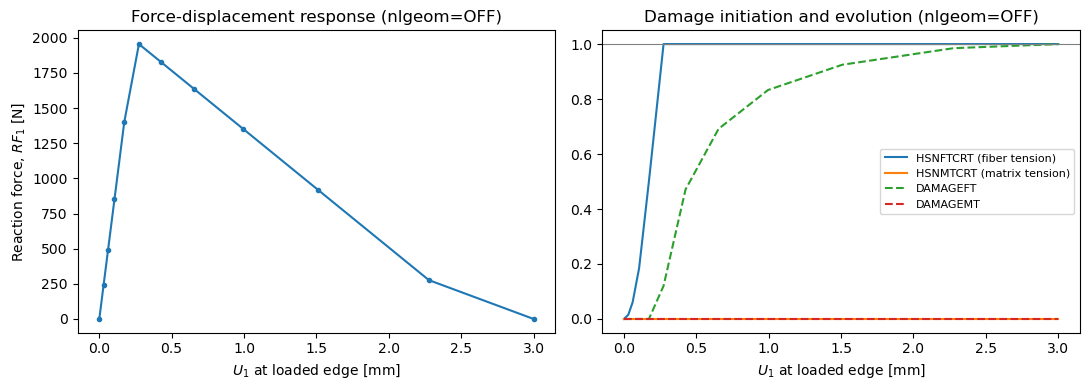

In [5]:
import json

import matplotlib.pyplot as plt
import numpy as np

# Load the JSON the script wrote out and pull each history/field-output array we need into a
# plain numpy array, so the plotting and reconstruction code below can use ordinary vectorized
# indexing instead of list comprehensions.
with open("../scripts/fiber_tension_results_nlgeom_off.json") as f:
    results_nlgeom_off = json.load(f)

u1_nlgeom_off = np.array(results_nlgeom_off["u1"])  # prescribed displacement at the loaded edge, mm -- one value per recorded increment
rf1_nlgeom_off = np.array(results_nlgeom_off["rf1"])  # total reaction force on the loaded edge, N (already summed across its two nodes -- see the script)
damage_ft_nlgeom_off = np.array(results_nlgeom_off["damage_ft"])  # fiber-tension damage variable d_ft, 0 (undamaged) to 1 (fully failed)
damage_mt_nlgeom_off = np.array(results_nlgeom_off["damage_mt"])  # matrix-tension damage variable d_mt
hsn_ft_nlgeom_off = np.array(results_nlgeom_off["hsn_ft"])  # fiber-tension Hashin criterion F_ft, reaches 1.0 at damage initiation
hsn_mt_nlgeom_off = np.array(results_nlgeom_off["hsn_mt"])  # matrix-tension Hashin criterion F_mt -- should stay ~0 for a clean uniaxial state

fig, axes = plt.subplots(1, 2, figsize=(11, 4))  # two panels side by side: raw response, then the damage/criterion variables

# RF1 here is read from X10-Edge, the *loaded* edge (see build_fiber_tension.py) — the
# reaction there is already positive under tension, so it's plotted directly (no sign
# flip, unlike the more common convention of reading it from the fixed edge instead).
axes[0].plot(u1_nlgeom_off, rf1_nlgeom_off, marker="o", ms=3)  # one marker per recorded Abaqus increment -- their spacing is itself informative, see below
axes[0].set_xlabel("$U_1$ at loaded edge [mm]")
axes[0].set_ylabel("Reaction force, $RF_1$ [N]")
axes[0].set_title("Force-displacement response (nlgeom=OFF)")

# The two Hashin criteria (solid lines) show when each failure mode *initiates* (crossing
# 1.0); the two damage variables (dashed lines) show how far each mode has *progressed* since.
axes[1].plot(u1_nlgeom_off, hsn_ft_nlgeom_off, label="HSNFTCRT (fiber tension)")
axes[1].plot(u1_nlgeom_off, hsn_mt_nlgeom_off, label="HSNMTCRT (matrix tension)")
axes[1].plot(u1_nlgeom_off, damage_ft_nlgeom_off, "--", label="DAMAGEFT")
axes[1].plot(u1_nlgeom_off, damage_mt_nlgeom_off, "--", label="DAMAGEMT")
axes[1].axhline(1.0, color="gray", lw=0.8)  # reference line: every criterion/damage variable here is bounded above by 1.0
axes[1].set_xlabel("$U_1$ at loaded edge [mm]")
axes[1].set_title("Damage initiation and evolution (nlgeom=OFF)")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

**Left panel**: the force rises linearly, peaks, then falls off along the softening
branch as $U_1$ keeps increasing — exactly the load-vs-displacement-control argument from
the theory section above playing out in practice. **Right panel**: `HSNFTCRT` is the only
criterion that ever reaches 1.0 (`HSNMTCRT` stays essentially at zero throughout, as the
boundary-condition discussion predicted), and `DAMAGEFT` then climbs from 0 to 1 over the
same displacement range the force is falling -- the damage variable doing exactly what
Step 6 of the theory above said it would.

The predictions above assume a perfectly bilinear, small-strain response sampled
continuously. The actual Abaqus run gives us that response only at the discrete set of
increments the solver chose to take — and, as the numbers below show, those
increments can land fairly coarsely right around the sharp features we care about most (the
peak, and the point where the fiber-tension mode fully fails), simply because Abaqus's
automatic step-size algorithm has no way to know in advance where those sharp features are.

**Two ways to deal with this.** One option is to manually cap the maximum increment
(`maxInc`) so the solver is forced to take smaller steps throughout — this
works, but it's a manual, per-analysis tuning choice, and taking small steps everywhere is
wasteful when only a narrow region actually needs fine resolution. The better general
solution would be to link the step-size growth rate to some quantity of interest, so the
solver automatically takes smaller steps as it approaches damage initiation and larger ones
once the response is well past it — **but Abaqus does not offer this** (at least not off-the-shelf); its automatic
increment adaptation is based purely on Newton-Raphson convergence behavior, not on proximity
to a physically interesting event.

**For this specific problem, we can do better without either of those**: we know from the
theory above that the true $\sigma$-$\delta$ (and hence force-displacement) response is
exactly **bilinear** around the peak, and exactly **linear** on the softening branch
approaching full failure. That means we can reconstruct both features geometrically from the
coarse data we already have:
- **Peak**: fit a straight line through the two points *before* `HSNFTCRT` reaches 1.0 (the
  elastic branch) and another through the two points *after* (the softening branch); their
  **intersection** is the reconstructed peak.
- **Full failure**: fit a straight line through the two points *before* `DAMAGEFT` reaches 1.0
  (already on the softening branch) and take its **zero-force crossing** as the reconstructed
  full-failure displacement.

First, though, let's look at the raw numbers straight off the simulated arrays, compared to the analytical predictions:

In [6]:
# Pull four "raw" (straight off the simulated increments, no reconstruction) quantities out
# of the arrays above, and print them next to the small-strain analytical predictions from
# earlier -- the gap between these two columns is what the reconstruction section below is
# going to close.
k_meas_nlgeom_off = rf1_nlgeom_off[1] / u1_nlgeom_off[1]  # elastic stiffness from the first non-zero increment
Fpeak_raw_nlgeom_off = rf1_nlgeom_off.max()  # the largest reaction force actually recorded
u1_at_raw_peak_nlgeom_off = u1_nlgeom_off[int(rf1_nlgeom_off.argmax())]  # the displacement at which that maximum occurs

# Full failure (DAMAGEFT=1.0 exactly) generally isn't itself a recorded increment, so bracket
# it instead: the last increment still short of it, and the first increment at (or past) it.
full_below_nlgeom_off = np.where(damage_ft_nlgeom_off < 0.999)[0]  # increments still short of full failure
full_above_nlgeom_off = np.where(damage_ft_nlgeom_off >= 0.999)[0]  # increments at (or past) full failure

print(f"{'quantity':32s}{'predicted':>12s}{'raw simulation':>22s}")
print("-" * 66)
print(f"{'elastic stiffness [N/mm]':32s}{k_pred:12.1f}{k_meas_nlgeom_off:22.1f}")
print(f"{'peak force [N]':32s}{Fpeak_pred:12.1f}{Fpeak_raw_nlgeom_off:22.1f}")
print(f"{'displacement at raw peak [mm]':32s}{delta0_pred:12.4f}{u1_at_raw_peak_nlgeom_off:22.4f}")
print(f"{'full-failure displacement [mm]':32s}{deltaf_pred:12.4f}"
      f"  bracket [{u1_nlgeom_off[full_below_nlgeom_off[-1]]:.4f}, {u1_nlgeom_off[full_above_nlgeom_off[0]]:.4f}]")
print()
# HSNMTCRT (the matrix-tension criterion) staying near zero throughout is the check that the
# boundary conditions really do produce a clean uniaxial state -- see NB1's BC discussion.
print(f"Max HSNMTCRT over the whole run: {hsn_mt_nlgeom_off.max():.2e} (should stay ~0 — confirms a "
      f"clean uniaxial state, no over-constraint artifact)")

quantity                           predicted        raw simulation
------------------------------------------------------------------
elastic stiffness [N/mm]              8120.0                8120.0
peak force [N]                        1980.0                1955.0
displacement at raw peak [mm]         0.2438                0.2738
full-failure displacement [mm]        2.6061  bracket [2.2766, 3.0000]

Max HSNMTCRT over the whole run: 5.45e-09 (should stay ~0 — confirms a clean uniaxial state, no over-constraint artifact)


### Reconstructing the peak and full-failure displacement

We define the reconstruction as two small helper functions once, here, and reuse them for
both the OFF run above and the ON run further below — the method doesn't depend on
`nlgeom`, only the two-branch bilinear/linear shape of the response established by the theory
section.

`HSNFTCRT` crosses 1.0 somewhere between two recorded increments; we fit the elastic line
through the two increments immediately *before* that crossing, and the softening line through
the two increments immediately *after* (and including) it — their intersection is the
reconstructed peak. Separately, we find the last two recorded increments where `DAMAGEFT` is
still below 1 (already on the softening branch) and extrapolate that line to zero force for
the reconstructed full-failure displacement. Both fits are through **exactly two points**, so
the fit is an exact line through those points, not a least-squares approximation over a larger number of points.

In [7]:
def line_through_two_points(x, y):
    """Slope and intercept of the exact line through two points (x[0], y[0]), (x[1], y[1])."""
    m = (y[1] - y[0]) / (x[1] - x[0])
    b = y[0] - m * x[0]
    return m, b


def reconstruct_peak(u1, rf1, hsn_ft):
    """Reconstruct the true peak by intersecting the elastic and softening branches either
    side of damage initiation."""
    init_idx = int(np.argmax(hsn_ft >= 1.0))  # first increment where the fiber-tension criterion reached 1.0
    elastic_idx = [init_idx - 2, init_idx - 1]  # two increments immediately before initiation
    softening_idx = [init_idx, init_idx + 1]  # two increments immediately after (and including) initiation

    m_elastic, b_elastic = line_through_two_points(u1[elastic_idx], rf1[elastic_idx])
    m_softening, b_softening = line_through_two_points(u1[softening_idx], rf1[softening_idx])

    # The two lines meet where m_elastic*u1 + b_elastic = m_softening*u1 + b_softening.
    u1_peak = (b_softening - b_elastic) / (m_elastic - m_softening)
    f_peak = m_elastic * u1_peak + b_elastic
    return u1_peak, f_peak, (m_elastic, b_elastic, elastic_idx), (m_softening, b_softening, softening_idx)


def reconstruct_full_failure(u1, rf1, damage_ft):
    """Extrapolate the softening branch's last two pre-failure increments to zero force."""
    full_idx = np.where(damage_ft < 0.999)[0][-2:]  # the two increments closest to (but before) full failure
    m_full, b_full = line_through_two_points(u1[full_idx], rf1[full_idx])
    u1_full = -b_full / m_full  # solve m_full*u1 + b_full = 0 for u1
    return u1_full, (m_full, b_full, full_idx)


# Apply both helpers to the OFF run's arrays -- the returned fit tuples (slope, intercept, the
# two-increment index pair) are kept around so the plot below can redraw each fitted line.
u1_peak_recon_nlgeom_off, Fpeak_recon_nlgeom_off, elastic_fit_nlgeom_off, softening_fit_nlgeom_off = reconstruct_peak(u1_nlgeom_off, rf1_nlgeom_off, hsn_ft_nlgeom_off)
u1_full_recon_nlgeom_off, full_fit_nlgeom_off = reconstruct_full_failure(u1_nlgeom_off, rf1_nlgeom_off, damage_ft_nlgeom_off)

print(f"Reconstructed peak (nlgeom OFF):          U1={u1_peak_recon_nlgeom_off:.4f} mm, F={Fpeak_recon_nlgeom_off:.1f} N")
print(f"Reconstructed full failure (nlgeom OFF):  U1={u1_full_recon_nlgeom_off:.4f} mm")

Reconstructed peak (nlgeom OFF):          U1=0.2438 mm, F=1980.0 N
Reconstructed full failure (nlgeom OFF):  U1=2.6061 mm


Reconstruction moves the peak from the raw reading of 1955.0 N at $U_1=0.2738$ mm to
1980.0 N at $U_1=0.2438$ mm — an essentially exact match to the analytical prediction — and puts
full failure at $U_1=2.6061$ mm, again matching the theory exactly. The plot below
shows *why*: it draws the two fitted lines (elastic branch and softening branch) through the
actual simulated increments, so you can see the intersection this reconstruction computed,
rather than trusting the printed numbers on faith.

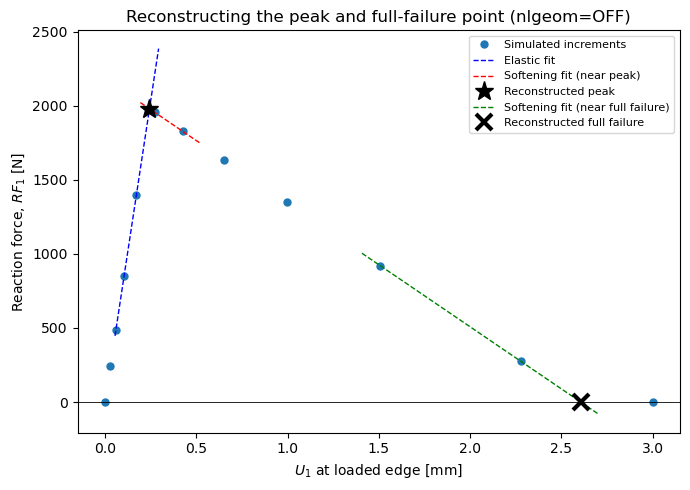

In [8]:
# Unpack each fit tuple (slope, intercept, index pair) back into named variables purely for
# readability in the plotting code below.
m_elastic_nlgeom_off, b_elastic_nlgeom_off, elastic_idx_nlgeom_off = elastic_fit_nlgeom_off
m_softening_nlgeom_off, b_softening_nlgeom_off, softening_idx_nlgeom_off = softening_fit_nlgeom_off
m_full_nlgeom_off, b_full_nlgeom_off, full_idx_nlgeom_off = full_fit_nlgeom_off

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(u1_nlgeom_off, rf1_nlgeom_off, "o", ms=5, color="C0", label="Simulated increments")  # every recorded increment, for reference

# extend each fitted line a little past its two fit points, purely so the intersection /
# zero-crossing point is visible on the plot
u1_e_line = np.array([u1_nlgeom_off[elastic_idx_nlgeom_off[0]] - 0.05, u1_peak_recon_nlgeom_off + 0.05])
u1_s_line = np.array([u1_peak_recon_nlgeom_off - 0.05, u1_nlgeom_off[softening_idx_nlgeom_off[1]] + 0.1])
ax.plot(u1_e_line, m_elastic_nlgeom_off * u1_e_line + b_elastic_nlgeom_off, "b--", lw=1, label="Elastic fit")  # line through the two pre-initiation increments
ax.plot(u1_s_line, m_softening_nlgeom_off * u1_s_line + b_softening_nlgeom_off, "r--", lw=1, label="Softening fit (near peak)")  # line through the two post-initiation increments
ax.plot(u1_peak_recon_nlgeom_off, Fpeak_recon_nlgeom_off, "k*", ms=14, label="Reconstructed peak")  # where the two lines above intersect

u1_f_line = np.array([u1_nlgeom_off[full_idx_nlgeom_off[0]] - 0.1, u1_full_recon_nlgeom_off + 0.1])
ax.plot(u1_f_line, m_full_nlgeom_off * u1_f_line + b_full_nlgeom_off, "g--", lw=1, label="Softening fit (near full failure)")  # line through the last two pre-failure increments
ax.plot(u1_full_recon_nlgeom_off, 0.0, "kx", ms=12, mew=3, label="Reconstructed full failure")  # where that line crosses zero force

ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("$U_1$ at loaded edge [mm]")
ax.set_ylabel("Reaction force, $RF_1$ [N]")
ax.set_title("Reconstructing the peak and full-failure point (nlgeom=OFF)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

The markers above are exactly the reconstructed values just printed — the star at the
elastic/softening intersection, the cross where the last-two-increment softening line
crosses zero force. The table below puts a number on how much closer these markers land to
the analytical prediction than the raw simulated peak and full-failure readings do.

In [9]:
# Three-way comparison table: the small-strain analytical prediction, the raw simulated value
# (straight off the recorded increments), and the reconstructed value (from the helper
# functions above). Elastic stiffness has no "reconstructed" entry -- it's read directly off
# the (already-linear) elastic branch, so there's nothing to reconstruct there.
print(f"{'quantity':30s}{'analytical':>12s}{'raw':>12s}{'reconstructed':>16s}")
print("-" * 70)
print(f"{'elastic stiffness [N/mm]':30s}{k_pred:12.1f}{k_meas_nlgeom_off:12.1f}{'--':>16s}")
print(f"{'peak force [N]':30s}{Fpeak_pred:12.1f}{Fpeak_raw_nlgeom_off:12.1f}{Fpeak_recon_nlgeom_off:16.1f}")
print(f"{'peak displacement [mm]':30s}{delta0_pred:12.4f}{u1_at_raw_peak_nlgeom_off:12.4f}{u1_peak_recon_nlgeom_off:16.4f}")
print(f"{'full-failure displacement [mm]':30s}{deltaf_pred:12.4f}{'--':>12s}{u1_full_recon_nlgeom_off:16.4f}")
print()
# Percentage gaps to the analytical prediction, raw vs. reconstructed -- this is the number
# that actually shows reconstruction doing its job, not just the raw table above.
print(f"Peak force: raw {abs(Fpeak_raw_nlgeom_off - Fpeak_pred) / Fpeak_pred:.2%} off analytical, "
      f"reconstructed {abs(Fpeak_recon_nlgeom_off - Fpeak_pred) / Fpeak_pred:.2%} off.")
print(f"Peak displacement: raw {abs(u1_at_raw_peak_nlgeom_off - delta0_pred) / delta0_pred:.2%} off analytical, "
      f"reconstructed {abs(u1_peak_recon_nlgeom_off - delta0_pred) / delta0_pred:.2%} off.")
print(f"Full-failure displacement: reconstructed "
      f"{abs(u1_full_recon_nlgeom_off - deltaf_pred) / deltaf_pred:.2%} off analytical.")

quantity                        analytical         raw   reconstructed
----------------------------------------------------------------------
elastic stiffness [N/mm]            8120.0      8120.0              --
peak force [N]                      1980.0      1955.0          1980.0
peak displacement [mm]              0.2438      0.2738          0.2438
full-failure displacement [mm]      2.6061          --          2.6061

Peak force: raw 1.26% off analytical, reconstructed 0.00% off.
Peak displacement: raw 12.27% off analytical, reconstructed 0.00% off.
Full-failure displacement: reconstructed 0.00% off analytical.


With `nlgeom=OFF`, reconstruction has closed the gap to zero: 0.00% off analytical
on both the peak force and peak displacement, and 0.00% off on full failure — confirming
the validity of the reconstruction method. The natural next question is what changes once geometric
nonlinearity enters the picture.

## Part B — repeating the analysis with geometric nonlinearity (`nlgeom=ON`)

With `nlgeom=OFF`, the reconstructed peak force, peak displacement, and full-failure displacement all matched the small-strain analytical predictions — confirming the validity of the reconstruction method, and highlighting that the only gap was the solver's discrete increment spacing.

Since it is typical, and often necessary, to run progressive damage analysis with geometric nonlinearity switched on, we now repeat the same analysis with `nlgeom=ON` to see what changes occur. After our previous study, we know that any gap to the analytical predictions that will appear in this run can be genuinely attributed to geometric nonlinearity, as long as the reconstruction method is applied again to correct for the solver's discrete increment spacing.

In [10]:
# Same pattern as Part A above, just with nlgeom=ON and its own output filename so this run
# can never collide with (or be shadowed by) the OFF run's result file.
results_nlgeom_on_path = Path("../scripts/fiber_tension_results_nlgeom_on.json")
results_nlgeom_on_path.unlink(missing_ok=True)  # so a stale file from a prior run can't masquerade as success

result_nlgeom_on = subprocess.run(
    [sys.executable, "build_fiber_tension.py", "nlgeom=ON", "X_T=990", "U1=3.0",
     "out=fiber_tension_results_nlgeom_on.json"],
    cwd="../scripts",
    capture_output=True,
    text=True,
)
print(result_nlgeom_on.stdout)
if result_nlgeom_on.stderr:
    print(result_nlgeom_on.stderr)

# Same caveat as Part A: result_nlgeom_on.returncode is always 0 regardless of whether Abaqus
# itself succeeded (abqpy's self-relaunch unconditionally exits 0 -- see CLAUDE.md), so the
# only reliable success signal is whether the script actually produced its output file.
if not results_nlgeom_on_path.exists():
    raise RuntimeError(
        "build_fiber_tension.py (nlgeom=ON) did not produce fiber_tension_results_nlgeom_on.json -- "
        "see the captured output above, and scripts/abaqus.rpy after a manual "
        "`abaqus cae noGUI=build_fiber_tension.py -- nlgeom=ON X_T=990 U1=3.0 "
        "out=fiber_tension_results_nlgeom_on.json` run, for the real Abaqus traceback."
    )

The script will be submitted to Abaqus next and the current Python session will be closed.

-------------------------------------------------------------------------------------------------------------------------------------------
Running the following command: abaqus cae noGUI=build_fiber_tension.py -- nlgeom=ON X_T=990 U1=3.0 out=fiber_tension_results_nlgeom_on.json
-------------------------------------------------------------------------------------------------------------------------------------------

Successfully checked out QAE/1 from DSLS server r1132101397472-eu1-licensing-1.3dexperience.3ds.com
Successfully checked out QAX/1 from DSLS server r1132101397472-eu1-licensing-2.3dexperience.3ds.com
Abaqus License Manager checked out the following license:
"QAE" from DSLS server r1132101397472-eu1-licensing-2.3dexperience.3ds.com
<26 out of 34 licenses remain available>.



### Reading and plotting the `nlgeom=ON` results

Same file format, same plots — with the `nlgeom=OFF` run curve overlaid for a direct visual
comparison.

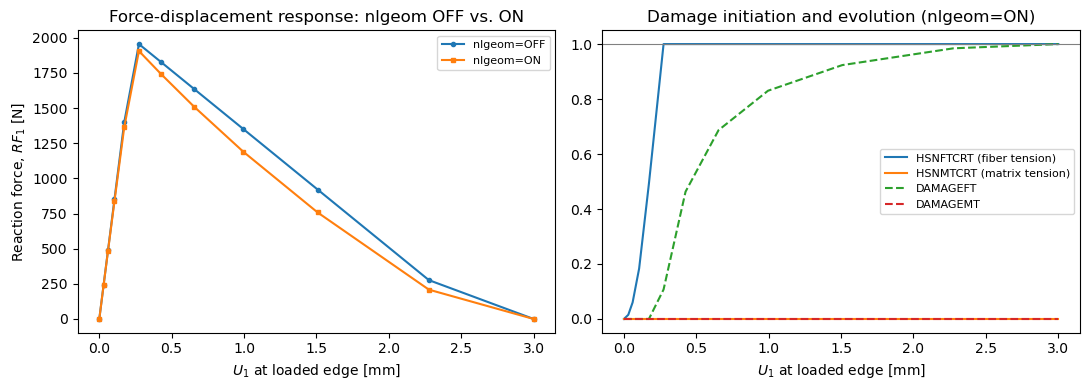

In [11]:
# Same JSON schema as the OFF run above -- load this run's own arrays the same way.
with open("../scripts/fiber_tension_results_nlgeom_on.json") as f:
    results_nlgeom_on = json.load(f)

u1_nlgeom_on = np.array(results_nlgeom_on["u1"])  # prescribed displacement at the loaded edge, mm
rf1_nlgeom_on = np.array(results_nlgeom_on["rf1"])  # total reaction force on the loaded edge, N
damage_ft_nlgeom_on = np.array(results_nlgeom_on["damage_ft"])  # fiber-tension damage variable d_ft
damage_mt_nlgeom_on = np.array(results_nlgeom_on["damage_mt"])  # matrix-tension damage variable d_mt
hsn_ft_nlgeom_on = np.array(results_nlgeom_on["hsn_ft"])  # fiber-tension Hashin criterion F_ft
hsn_mt_nlgeom_on = np.array(results_nlgeom_on["hsn_mt"])  # matrix-tension Hashin criterion F_mt -- should stay ~0 regardless of nlgeom

fig, axes = plt.subplots(1, 2, figsize=(11, 4))  # same two-panel layout as the OFF run above

# Left panel overlays both runs directly, so any difference between OFF and ON is visible at
# a glance rather than having to compare two separate figures.
axes[0].plot(u1_nlgeom_off, rf1_nlgeom_off, marker="o", ms=3, label="nlgeom=OFF")
axes[0].plot(u1_nlgeom_on, rf1_nlgeom_on, marker="s", ms=3, label="nlgeom=ON")
axes[0].set_xlabel("$U_1$ at loaded edge [mm]")
axes[0].set_ylabel("Reaction force, $RF_1$ [N]")
axes[0].set_title("Force-displacement response: nlgeom OFF vs. ON")
axes[0].legend(fontsize=8)

# Right panel is the ON run's own damage/criterion variables only (same layout as the OFF
# run's right panel above) -- compare the two figures directly to see what nlgeom=ON changes.
axes[1].plot(u1_nlgeom_on, hsn_ft_nlgeom_on, label="HSNFTCRT (fiber tension)")
axes[1].plot(u1_nlgeom_on, hsn_mt_nlgeom_on, label="HSNMTCRT (matrix tension)")
axes[1].plot(u1_nlgeom_on, damage_ft_nlgeom_on, "--", label="DAMAGEFT")
axes[1].plot(u1_nlgeom_on, damage_mt_nlgeom_on, "--", label="DAMAGEMT")
axes[1].axhline(1.0, color="gray", lw=0.8)
axes[1].set_xlabel("$U_1$ at loaded edge [mm]")
axes[1].set_title("Damage initiation and evolution (nlgeom=ON)")
axes[1].legend(fontsize=8)

fig.tight_layout()
plt.show()

The overlay in the left panel shows the two curves nearly coincide up to the peak, then
diverge slightly on the softening branch — consistent with the small, systematic shift the
equations below explain. The right panel confirms the same clean picture as the OFF run
above: only `HSNFTCRT`/`DAMAGEFT` move meaningfully, while `HSNMTCRT` stays flat at zero.

### Comparing the `nlgeom=ON` run response to the analytical predictions

Same raw comparison as Part A, now for the `nlgeom=ON` run.

In [12]:
# Same raw comparison as Part A's cell above, computed from the ON run's own arrays.
k_meas_nlgeom_on = rf1_nlgeom_on[1] / u1_nlgeom_on[1]  # elastic stiffness from the first non-zero increment
Fpeak_raw_nlgeom_on = rf1_nlgeom_on.max()  # the largest reaction force actually recorded
u1_at_raw_peak_nlgeom_on = u1_nlgeom_on[int(rf1_nlgeom_on.argmax())]  # the displacement at which that maximum occurs

full_below_nlgeom_on = np.where(damage_ft_nlgeom_on < 0.999)[0]  # increments still short of full failure
full_above_nlgeom_on = np.where(damage_ft_nlgeom_on >= 0.999)[0]  # increments at (or past) full failure

print(f"{'quantity':32s}{'predicted':>12s}{'raw simulation':>22s}")
print("-" * 66)
print(f"{'elastic stiffness [N/mm]':32s}{k_pred:12.1f}{k_meas_nlgeom_on:22.1f}")
print(f"{'peak force [N]':32s}{Fpeak_pred:12.1f}{Fpeak_raw_nlgeom_on:22.1f}")
print(f"{'displacement at raw peak [mm]':32s}{delta0_pred:12.4f}{u1_at_raw_peak_nlgeom_on:22.4f}")
print(f"{'full-failure displacement [mm]':32s}{deltaf_pred:12.4f}"
      f"  bracket [{u1_nlgeom_on[full_below_nlgeom_on[-1]]:.4f}, {u1_nlgeom_on[full_above_nlgeom_on[0]]:.4f}]")
print()
# Same HSNMTCRT check as Part A -- staying near zero confirms the clean uniaxial state holds
# regardless of the nlgeom setting.
print(f"Max HSNMTCRT over the whole run: {hsn_mt_nlgeom_on.max():.2e} (should stay ~0 -- confirms a "
      f"clean uniaxial state, no over-constraint artifact, regardless of nlgeom)")

quantity                           predicted        raw simulation
------------------------------------------------------------------
elastic stiffness [N/mm]              8120.0                8083.6
peak force [N]                        1980.0                1905.6
displacement at raw peak [mm]         0.2438                0.2738
full-failure displacement [mm]        2.6061  bracket [2.2766, 3.0000]

Max HSNMTCRT over the whole run: 1.11e-08 (should stay ~0 -- confirms a clean uniaxial state, no over-constraint artifact, regardless of nlgeom)


Same raw comparison as Part A's cell above, right down to the same double-digit gap in
the raw peak displacement — let's see whether reconstruction closes it here too.

In [13]:
# Apply the same two reconstruction helpers to the ON run's arrays.
u1_peak_recon_nlgeom_on, Fpeak_recon_nlgeom_on, elastic_fit_nlgeom_on, softening_fit_nlgeom_on = reconstruct_peak(u1_nlgeom_on, rf1_nlgeom_on, hsn_ft_nlgeom_on)
u1_full_recon_nlgeom_on, full_fit_nlgeom_on = reconstruct_full_failure(u1_nlgeom_on, rf1_nlgeom_on, damage_ft_nlgeom_on)

print(f"Reconstructed peak (nlgeom ON):          U1={u1_peak_recon_nlgeom_on:.4f} mm, F={Fpeak_recon_nlgeom_on:.1f} N")
print(f"Reconstructed full failure (nlgeom ON):  U1={u1_full_recon_nlgeom_on:.4f} mm")

Reconstructed peak (nlgeom ON):          U1=0.2457 mm, F=1935.7 N
Reconstructed full failure (nlgeom ON):  U1=2.5685 mm


Reconstruction now lands close to, but not exactly on, the analytical prediction
($F=1935.7$ N at $U_1=0.2457$ mm, vs. an analytical 1980.0 N at 0.2438 mm) — a small
residual gap the next section explains, rather than a reconstruction failure. The plot below
draws the same elastic/softening fits as the OFF run above, this time for the ON data.

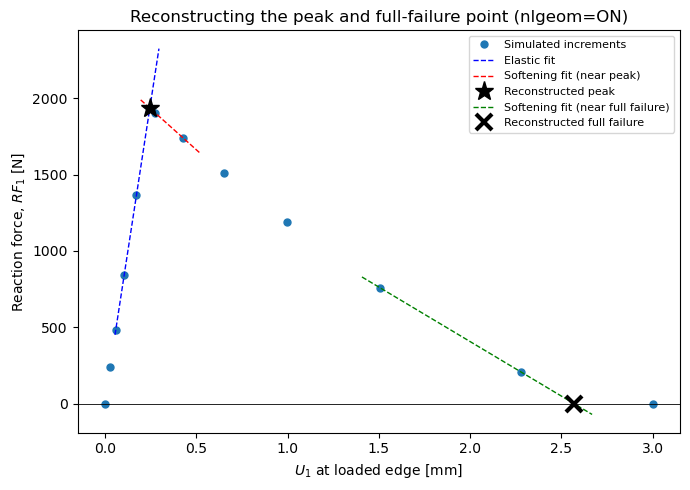

In [14]:
# Same plot as the OFF reconstruction above, redrawn for the ON run.
m_elastic_nlgeom_on, b_elastic_nlgeom_on, elastic_idx_nlgeom_on = elastic_fit_nlgeom_on
m_softening_nlgeom_on, b_softening_nlgeom_on, softening_idx_nlgeom_on = softening_fit_nlgeom_on
m_full_nlgeom_on, b_full_nlgeom_on, full_idx_nlgeom_on = full_fit_nlgeom_on

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(u1_nlgeom_on, rf1_nlgeom_on, "o", ms=5, color="C0", label="Simulated increments")  # every recorded increment, for reference

u1_e_line = np.array([u1_nlgeom_on[elastic_idx_nlgeom_on[0]] - 0.05, u1_peak_recon_nlgeom_on + 0.05])
u1_s_line = np.array([u1_peak_recon_nlgeom_on - 0.05, u1_nlgeom_on[softening_idx_nlgeom_on[1]] + 0.1])
ax.plot(u1_e_line, m_elastic_nlgeom_on * u1_e_line + b_elastic_nlgeom_on, "b--", lw=1, label="Elastic fit")  # line through the two pre-initiation increments
ax.plot(u1_s_line, m_softening_nlgeom_on * u1_s_line + b_softening_nlgeom_on, "r--", lw=1, label="Softening fit (near peak)")  # line through the two post-initiation increments
ax.plot(u1_peak_recon_nlgeom_on, Fpeak_recon_nlgeom_on, "k*", ms=14, label="Reconstructed peak")  # where the two lines above intersect

u1_f_line = np.array([u1_nlgeom_on[full_idx_nlgeom_on[0]] - 0.1, u1_full_recon_nlgeom_on + 0.1])
ax.plot(u1_f_line, m_full_nlgeom_on * u1_f_line + b_full_nlgeom_on, "g--", lw=1, label="Softening fit (near full failure)")  # line through the last two pre-failure increments
ax.plot(u1_full_recon_nlgeom_on, 0.0, "kx", ms=12, mew=3, label="Reconstructed full failure")  # where that line crosses zero force

ax.axhline(0, color="k", lw=0.6)
ax.set_xlabel("$U_1$ at loaded edge [mm]")
ax.set_ylabel("Reaction force, $RF_1$ [N]")
ax.set_title("Reconstructing the peak and full-failure point (nlgeom=ON)")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

As with the OFF run, the markers above are exactly the numbers just printed. The table
below sets them against the raw reading and the analytical prediction side by side.

In [15]:
# Same three-way comparison table as Part A, now for the ON run.
print(f"{'quantity':30s}{'analytical':>12s}{'raw':>12s}{'reconstructed':>16s}")
print("-" * 70)
print(f"{'elastic stiffness [N/mm]':30s}{k_pred:12.1f}{k_meas_nlgeom_on:12.1f}{'--':>16s}")
print(f"{'peak force [N]':30s}{Fpeak_pred:12.1f}{Fpeak_raw_nlgeom_on:12.1f}{Fpeak_recon_nlgeom_on:16.1f}")
print(f"{'peak displacement [mm]':30s}{delta0_pred:12.4f}{u1_at_raw_peak_nlgeom_on:12.4f}{u1_peak_recon_nlgeom_on:16.4f}")
print(f"{'full-failure displacement [mm]':30s}{deltaf_pred:12.4f}{'--':>12s}{u1_full_recon_nlgeom_on:16.4f}")
print()
print(f"Peak force: raw {abs(Fpeak_raw_nlgeom_on - Fpeak_pred) / Fpeak_pred:.2%} off analytical, "
      f"reconstructed {abs(Fpeak_recon_nlgeom_on - Fpeak_pred) / Fpeak_pred:.2%} off.")
print(f"Peak displacement: raw {abs(u1_at_raw_peak_nlgeom_on - delta0_pred) / delta0_pred:.2%} off analytical, "
      f"reconstructed {abs(u1_peak_recon_nlgeom_on - delta0_pred) / delta0_pred:.2%} off.")
print(f"Full-failure displacement: reconstructed "
      f"{abs(u1_full_recon_nlgeom_on - deltaf_pred) / deltaf_pred:.2%} off analytical.")

quantity                        analytical         raw   reconstructed
----------------------------------------------------------------------
elastic stiffness [N/mm]            8120.0      8083.6              --
peak force [N]                      1980.0      1905.6          1935.7
peak displacement [mm]              0.2438      0.2738          0.2457
full-failure displacement [mm]      2.6061          --          2.5685

Peak force: raw 3.76% off analytical, reconstructed 2.24% off.
Peak displacement: raw 12.27% off analytical, reconstructed 0.77% off.
Full-failure displacement: reconstructed 1.44% off analytical.


### Why `nlgeom=ON` moves the peak: the equations

Two genuine effects separate the ON run from the OFF run, both consequences of
accounting for finite deformation rather than assuming small strain:

**1. Strain measure.** With `nlgeom=OFF`, strain is the small-strain engineering strain
$\varepsilon_{\text{eng}}=U_1/L$. With `nlgeom=ON`, Abaqus uses the logarithmic (true) strain,
$$
\varepsilon_{\log} = \ln\!\left(1+\frac{U_1}{L}\right) < \varepsilon_{\text{eng}} \quad
\text{for } U_1>0,
$$
so reaching the same *stress* level $X_T$ takes a slightly larger prescribed displacement
$U_1$ under `nlgeom=ON` than the small-strain formula $\delta_0=(X_T/E_1)L$ predicts — shifting
the initiation (and hence peak) displacement.

**2. Stress measure and the shrinking cross-section.** With `nlgeom=OFF`, force is simply
stress times the *original* area, $F=X_T A_0$. With `nlgeom=ON`, Abaqus works with the true
(Cauchy) stress acting on the *current*, deformed cross-section, which has contracted under
the applied tensile strain through Poisson's ratio — the in-plane contraction alone already
gives the dominant part of the effect, using the one Poisson's ratio the material table
actually reports, $\nu_{12}=0.27$:
$$
F_\text{peak} = X_T\,A_\text{current}, \qquad
A_\text{current} \approx A_0\,(1-\nu_{12}\varepsilon_{11}) < A_0,
$$
so the same fiber-direction strength $X_T$ now corresponds to a *smaller* peak force than the
reference-area formula $F_\text{peak}=X_T A_0$ gives.

Both effects push the same way — toward a peak that is reached at a *slightly larger*
displacement and carries a *slightly smaller* force than the small-strain formulas predict —
which is exactly the direction the numbers above show. The cell below makes the size of that
gap concrete by comparing the two runs' own reconstructed values directly against each other,
rather than each separately against the analytical prediction.

In [16]:
# Direct OFF-vs-ON comparison of the reconstructed values only (the numbers already shown to
# be the most accurate above) -- isolates exactly what turning nlgeom ON changes, without the
# raw-reading noise either run's table above already explained.
print(f"{'quantity':32s}{'nlgeom OFF (reconstructed)':>22s}{'nlgeom ON (reconstructed)':>22s}{'difference':>14s}")
print("-" * 90)
print(f"{'peak force [N]':32s}{Fpeak_recon_nlgeom_off:22.1f}{Fpeak_recon_nlgeom_on:22.1f}"
      f"{(Fpeak_recon_nlgeom_on - Fpeak_recon_nlgeom_off):14.1f}")
print(f"{'peak displacement [mm]':32s}{u1_peak_recon_nlgeom_off:22.4f}{u1_peak_recon_nlgeom_on:22.4f}"
      f"{(u1_peak_recon_nlgeom_on - u1_peak_recon_nlgeom_off):14.4f}")
print(f"{'full-failure displacement [mm]':32s}{u1_full_recon_nlgeom_off:22.4f}{u1_full_recon_nlgeom_on:22.4f}"
      f"{(u1_full_recon_nlgeom_on - u1_full_recon_nlgeom_off):14.4f}")
print()
print(f"Turning nlgeom ON alone shifts the reconstructed peak force by "
      f"{(Fpeak_recon_nlgeom_off - Fpeak_recon_nlgeom_on) / Fpeak_recon_nlgeom_off:.2%} and the reconstructed peak "
      f"displacement by {(u1_peak_recon_nlgeom_on - u1_peak_recon_nlgeom_off) / u1_peak_recon_nlgeom_off:.2%}, "
      f"both in the direction the equations above predict.")

quantity                        nlgeom OFF (reconstructed)nlgeom ON (reconstructed)    difference
------------------------------------------------------------------------------------------
peak force [N]                                  1980.0                1935.7         -44.3
peak displacement [mm]                          0.2438                0.2457        0.0019
full-failure displacement [mm]                  2.6061                2.5685       -0.0376

Turning nlgeom ON alone shifts the reconstructed peak force by 2.24% and the reconstructed peak displacement by 0.77%, both in the direction the equations above predict.


**What this shows.** With `nlgeom=OFF`, reconstruction resolves essentially all of the raw
gap to the analytical predictions — the reconstructed peak force, peak displacement, and
full-failure displacement all land essentially equal to the small-strain
formulas, which is exactly what should happen when the element formulation matches the
formulas' own assumptions and only the solver's discrete increment spacing stands
between the simulation and the theory. The raw values, by contrast, are off by a much larger
margin purely because of where the solver's automatic step-size choice happened to land its
increments — not because anything is wrong with the model.

With `nlgeom=ON`, the *same* reconstruction procedure leaves a small but genuine residual gap
to the analytical predictions — a few percent, not the double-digit gap the raw readings show
— consistent with the geometric-nonlinearity equations above: the logarithmic-strain and
shrinking-cross-section effects both push the true peak to a slightly larger displacement and
slightly smaller force than the small-strain formulas assume, and both are genuinely present
only once `nlgeom=ON`. And `HSNMTCRT` stays effectively at 0 for every increment of *both*
runs, confirming the boundary-condition scheme produces a genuinely clean uniaxial state with
no parasitic transverse stress at all, regardless of the nlgeom setting.

## Conclusion

This notebook took the four ingredients of a progressive damage analysis — a
damage-initiation criterion, an energy-based evolution law, stiffness degradation fed back
into the constitutive response, and a solver able to trace the resulting unstable path — and
verified each of them against a single, deliberately minimal test: one Abaqus S4R shell
element, one ply, pure fiber-direction tension, run **twice** — once with `nlgeom=OFF`, once
with `nlgeom=ON` — to separate discretization artifacts from genuine nonlinear kinematics.

**What these two runs actually confirmed:**

- With `nlgeom=OFF`, the reconstructed elastic stiffness, peak force, peak displacement, and
  full-failure displacement all match the small-strain analytical formulas closely, validating the peak/full-failure reconstruction method on a case where they should agree exactly.
- With `nlgeom=ON`, the same reconstruction leaves a small residual gap to the analytical
  predictions, and that gap is explained — not just observed — by the logarithmic-strain and
  shrinking-current-cross-section effects that only apply once geometric nonlinearity is
  switched on.
- In both runs, the raw force-displacement curve, read directly off the solver's
  own increments, under- and over-shoots the true peak force and displacement by a few to over
  ten percent — not because anything is wrong with the model, but because the solver's
  automatic step-size choice has no way to know in advance where the sharp features of the
  response are. Reconstructing the peak (by intersecting the elastic and softening branches)
  and the full-failure point (by extrapolating the softening branch to zero force) recovers
  both far more accurately in every case.
- `HSNMTCRT` stays at exactly (or effectively) 0 for every increment of both runs, confirming
  the essential (rigid-body-removing, but no more) boundary-condition scheme genuinely
  produces a clean uniaxial state with no parasitic transverse stress, independent of the
  nlgeom setting.
- `DAMAGEFT` climbs from 0 to 1 over a displacement range whose reconstructed endpoint matches
  $\delta_f=2G_{fT}/X_T$ closely in both runs, confirming the fracture energy really does
  control the *length* of the softening branch, as the theory predicted.

**Where this goes next.** This verified single-element model is the starting point for
`notebooks/02_monte_carlo_fiber_strength.ipynb`, which treats the fiber tensile strength $X_T$
itself as *uncertain* — a random variable rather than a fixed 990 MPa — and propagates that
uncertainty through to the peak force, reusing this exact `build_fiber_tension.py` script
(with an `X_T` override) and the same two-line-fit peak-reconstruction technique verified
above. It runs the identical `nlgeom=OFF`/`nlgeom=ON` pair as two complete Monte Carlo
campaigns, so the same discretization-vs-nonlinear-kinematics distinction drawn here reappears
at the population level, not just for one baseline point.